# 🕉️ ShlokaSage — QLoRA Fine-Tuning with Ablation Study

Fine-tunes Llama 3.1 8B Instruct using QLoRA via Unsloth on Kaggle T4 GPU.

**Features:**
- 5-run hyperparameter ablation study
- Auto-evaluation (ROUGE-L, BLEU, Citation F1, BERTScore) per run
- Auto-save model weights + metrics to HuggingFace Hub
- Training curves saved per run

**Setup:** Upload `train.jsonl`, `test.jsonl`, `test_with_metadata.json` as Kaggle dataset. Add `HF_TOKEN` in Kaggle Secrets.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
# ─── Step 1: Install Dependencies ───────────────────────────
!pip install -q unsloth
!pip install -q --no-deps trl peft accelerate bitsandbytes
!pip install -q datasets huggingface_hub bert-score rouge-score nltk
!pip install -q "transformers>=5.2.0,<=5.5.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 MB 26.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 96.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 100.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.4/924.4 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 90.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.3 MB/s eta 

In [3]:
# ─── Step 1b: Fix Transformers Version ─────────────────────
!pip install -q transformers==5.5.0 --force-reinstall --no-deps
import transformers
print(f"Transformers version: {transformers.__version__}")
# Must show 5.5.0 — if not, restart kernel and rerun

Transformers version: 5.5.0


In [6]:
# ─── Step 2: Configuration ─────────────────────────────────
# ⚠️ CHANGE THESE FOR EACH RUN ⚠️

RUN_NAME = "run1_baseline"  # Change per run: run1_baseline, run2_rank8, run3_rank32, run4_epoch5, run5_lr5e5

# Hyperparameters for this run
LORA_RANK = 16         # Run1: 16, Run2: 8, Run3: 32, Run4: 16, Run5: 16
LORA_ALPHA = 16        # Run1: 16, Run2: 8, Run3: 32, Run4: 16, Run5: 16
NUM_EPOCHS = 3         # Run1: 3,  Run2: 3, Run3: 3,  Run4: 5,  Run5: 3
LEARNING_RATE = 2e-4   # Run1: 2e-4, Run2: 2e-4, Run3: 2e-4, Run4: 2e-4, Run5: 5e-5
BATCH_SIZE = 1
GRAD_ACCUM = 8         # Effective batch = BATCH_SIZE * GRAD_ACCUM = 8
MAX_SEQ_LENGTH = 2048

# HuggingFace config
HF_USERNAME = "mayankgocher"
BASE_REPO = f"{HF_USERNAME}/ShlokaSage-Llama3.1-8B"

# Dataset paths (adjust based on your Kaggle dataset upload)
TRAIN_PATH = "/kaggle/input/datasets/mayankgocher/shlokasage-dataset/train.jsonl"
TEST_PATH = "/kaggle/input/datasets/mayankgocher/shlokasage-dataset/test.jsonl"
TEST_META_PATH = "/kaggle/input/datasets/mayankgocher/shlokasage-dataset/test_with_metadata.json"

print(f"Run: {RUN_NAME}")
print(f"Config: rank={LORA_RANK}, alpha={LORA_ALPHA}, epochs={NUM_EPOCHS}, lr={LEARNING_RATE}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")

Run: run1_baseline
Config: rank=16, alpha=16, epochs=3, lr=0.0002
Effective batch size: 8


In [7]:
# ─── Step 3: Login to HuggingFace ─────────────────────────
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

secrets = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("✅ Logged into HuggingFace Hub")

✅ Logged into HuggingFace Hub


In [8]:
# ─── Step 4: Load Base Model ──────────────────────────────
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

print(f"✅ Base model loaded. Parameters: {model.num_parameters():,}")

/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:165: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.1: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

Unsloth: Will load unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit as a legacy tokenizer.


✅ Base model loaded. Parameters: 8,030,261,248


In [9]:
# ─── Step 5: Add LoRA Adapters ────────────────────────────
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_RANK,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"✅ LoRA adapters added (rank={LORA_RANK}, alpha={LORA_ALPHA})")
print(f"   Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

Unsloth 2026.6.1 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ LoRA adapters added (rank=16, alpha=16)
   Trainable: 41,943,040 / 4,582,543,360 (0.92%)


In [10]:
# ─── Step 6: Load & Format Dataset ────────────────────────
from datasets import load_dataset

dataset = load_dataset("json", data_files={
    "train": TRAIN_PATH,
    "test": TEST_PATH,
})

def apply_chat_template(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

formatted_dataset = dataset.map(apply_chat_template)

# Token length stats
sample_lengths = []
for i in range(min(50, len(formatted_dataset['train']))):
    tokens = tokenizer(formatted_dataset['train'][i]['text'], return_length=True)
    sample_lengths.append(tokens['length'][0])

print(f"✅ Dataset loaded. Train: {len(formatted_dataset['train'])} | Test: {len(formatted_dataset['test'])}")
print(f"   Token lengths (sample): min={min(sample_lengths)}, max={max(sample_lengths)}, avg={sum(sample_lengths)//len(sample_lengths)}")

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1353 [00:00<?, ? examples/s]

Map:   0%|          | 0/148 [00:00<?, ? examples/s]

✅ Dataset loaded. Train: 1353 | Test: 148
   Token lengths (sample): min=505, max=1024, avg=635


In [10]:
lengths = [len(tokenizer(formatted_dataset['train'][i]['text'])['input_ids']) for i in range(len(formatted_dataset['train']))]
print(f"Max: {max(lengths)}, 95th pct: {sorted(lengths)[int(len(lengths)*0.95)]}, median: {sorted(lengths)[len(lengths)//2]}")

Max: 1153, 95th pct: 967, median: 590


In [11]:
# ─── Step 7: Configure Trainer ────────────────────────────
from trl import SFTTrainer
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

output_dir = f"/kaggle/working/{RUN_NAME}"

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=formatted_dataset["train"],
    eval_dataset=formatted_dataset["test"],
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    dataset_num_proc=1,
    packing=False,
    args=TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        weight_decay=0.01,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=5,
        eval_strategy="steps",
        eval_steps=25,
        save_strategy="no",
        optim="adamw_8bit",
        seed=42,
        average_tokens_across_devices=False,
        report_to="none",
    ),
)

# GPU info
gpu_stats = torch.cuda.get_device_properties(0)
reserved = torch.cuda.max_memory_reserved() / 1024**3
print(f"✅ Trainer configured")
print(f"   GPU: {gpu_stats.name} | {gpu_stats.total_memory/1024**3:.1f}GB total | {reserved:.1f}GB reserved")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1353 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/148 [00:00<?, ? examples/s]

✅ Trainer configured
   GPU: Tesla T4 | 14.6GB total | 5.5GB reserved


In [12]:
# ─── Step 8: Train ────────────────────────────────────────
import time

start_time = time.time()
trainer_stats = trainer.train()
train_time = time.time() - start_time

print(f"\n{'='*50}")
print(f"✅ Training complete: {RUN_NAME}")
print(f"   Steps: {trainer_stats.global_step}")
print(f"   Training loss: {trainer_stats.training_loss:.4f}")
print(f"   Runtime: {train_time:.0f}s ({train_time/60:.1f} min)")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,353 | Num Epochs = 3 | Total steps = 510
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss,Validation Loss
25,0.960975,0.901853
50,0.818099,0.768094
75,0.719847,0.716693
100,0.737046,0.692883
125,0.639308,0.674180
150,0.630684,0.655111
175,0.617048,0.647958
200,0.538674,0.631380
225,0.558965,0.612428
250,0.521717,0.603432


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API i


✅ Training complete: run1_baseline
   Steps: 510
   Training loss: 0.5823
   Runtime: 8007s (133.4 min)


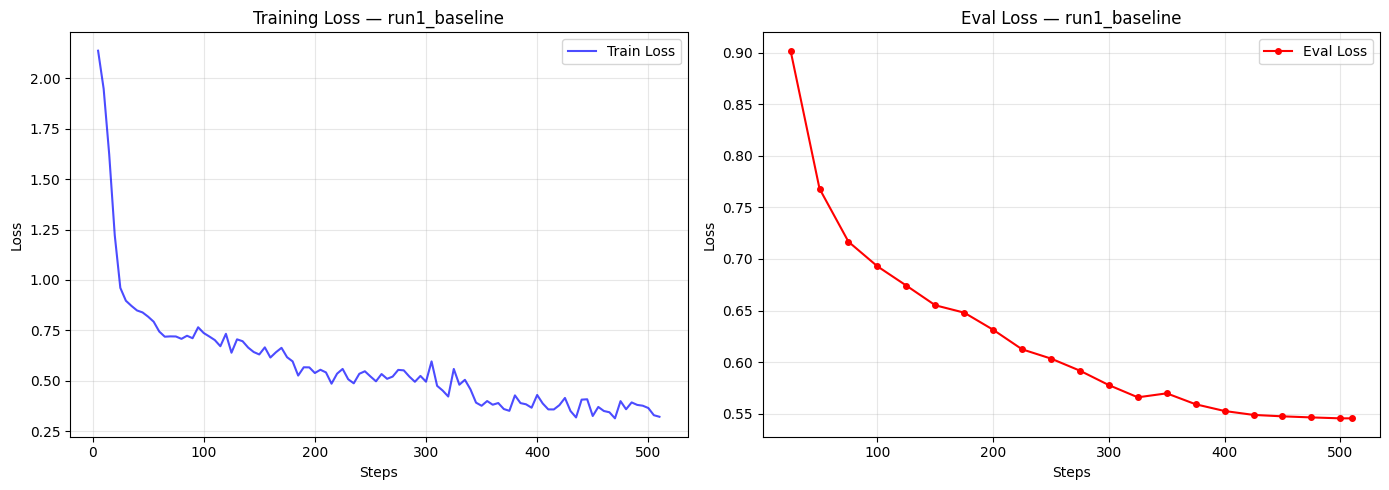

Saved to /kaggle/working/run1_baseline_curves.png


In [13]:
# ─── Step 9: Plot Training Curves ─────────────────────────
import matplotlib.pyplot as plt
import json

log_history = trainer.state.log_history

train_losses = [(x['step'], x['loss']) for x in log_history if 'loss' in x]
eval_losses = [(x['step'], x['eval_loss']) for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
if train_losses:
    steps, losses = zip(*train_losses)
    axes[0].plot(steps, losses, 'b-', alpha=0.7, label='Train Loss')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'Training Loss — {RUN_NAME}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Eval loss
if eval_losses:
    steps, losses = zip(*eval_losses)
    axes[1].plot(steps, losses, 'r-o', markersize=4, label='Eval Loss')
    axes[1].set_xlabel('Steps')
    axes[1].set_ylabel('Loss')
    axes[1].set_title(f'Eval Loss — {RUN_NAME}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
curves_path = f"/kaggle/working/{RUN_NAME}_curves.png"
plt.savefig(curves_path, dpi=150)
plt.show()
print(f"Saved to {curves_path}")

# Save log history as JSON
with open(f"/kaggle/working/{RUN_NAME}_logs.json", "w") as f:
    json.dump(log_history, f, indent=2)

In [14]:
# ─── Step 10: Generate Test Responses ─────────────────────
import json

FastLanguageModel.for_inference(model)

with open(TEST_META_PATH, "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Generating responses for {len(test_data)} test examples...")

responses = []
for i, item in enumerate(test_data):
    messages = [
        {"role": "system", "content": item["messages"][0]["content"]},
        {"role": "user", "content": item["question"]},
    ]
    
    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=512,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
        )
    
    response = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    responses.append({
        "question": item["question"],
        "ground_truth": item["ground_truth"],
        "response": response,
        "type": item["type"],
    })
    
    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(test_data)} done")

# Save responses
resp_path = f"/kaggle/working/{RUN_NAME}_responses.json"
with open(resp_path, "w", encoding="utf-8") as f:
    json.dump(responses, f, ensure_ascii=False, indent=2)
print(f"\n✅ Saved {len(responses)} responses to {resp_path}")

# Print a sample
print(f"\n--- Sample ---")
print(f"Q: {responses[0]['question']}")
print(f"A: {responses[0]['response'][:300]}...")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generating responses for 148 test examples...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

  25/148 done


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

...

  100/148 done


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_

  125/148 done


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_


✅ Saved 148 responses to /kaggle/working/run1_baseline_responses.json

--- Sample ---
Q: What is the alternative practice recommended in Bhagavad Gita Chapter 12, Verse 9, if one finds it difficult to fix their mind on Krishna?
A: The Bhagavad Gita, Chapter 12, Verse 9, offers a compassionate alternative for devotees who face difficulty in focusing their minds solely on the Divine. The verse states:

SANSKRIT: यदा हि नेन्द्रियग्रामः स्वरूपसंनुद्धरन् |
नकुलितोऽपि से योगो दुष्प्राप इति मे मतिः ||१२-९||

TRANSLITERATION: yadā hi...


In [15]:
# ─── Step 11: Evaluate Metrics ────────────────────────────
import re
import numpy as np
from rouge_score import rouge_scorer
from collections import defaultdict
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# ── Verse Citation Accuracy ──
def extract_verse_citations(text):
    patterns = [
        r'BG\s*(\d{1,2})\.(\d{1,3})',
        r'Chapter\s*(\d{1,2})\s*[,.]?\s*Verse\s*(\d{1,3})',
        r'(\d{1,2})\.(\d{1,3})',
    ]
    citations = set()
    for pattern in patterns:
        for ch, v in re.findall(pattern, text, re.IGNORECASE):
            citations.add(f"{int(ch)}.{int(v)}")
    return citations

# ── Compute all metrics ──
rouge = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
smooth = SmoothingFunction().method1

rouge_scores = []
bleu_scores = []
citation_f1s = []
all_preds = []
all_refs = []

for item in responses:
    gt = item["ground_truth"]
    pred = item["response"]
    
    # ROUGE-L
    r = rouge.score(gt, pred)
    rouge_scores.append(r['rougeL'].fmeasure)
    
    # BLEU
    ref_tokens = gt.lower().split()
    pred_tokens = pred.lower().split()
    if len(ref_tokens) > 0 and len(pred_tokens) > 0:
        b = sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smooth)
        bleu_scores.append(b)
    
    # Citation F1
    gt_cites = extract_verse_citations(gt)
    pred_cites = extract_verse_citations(pred)
    if gt_cites:
        correct = gt_cites & pred_cites
        prec = len(correct) / len(pred_cites) if pred_cites else 0
        rec = len(correct) / len(gt_cites) if gt_cites else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        citation_f1s.append(f1)
    
    # For BERTScore
    all_preds.append(pred)
    all_refs.append(gt)

# BERTScore (batched)
print("Computing BERTScore (this takes a minute)...")
from bert_score import score as bert_score_fn
P, R, F1 = bert_score_fn(all_preds, all_refs, lang="en", verbose=False, device="cuda")
bertscore_f1 = F1.mean().item()

# ── Summary ──
final_eval_loss = None
for x in reversed(log_history):
    if 'eval_loss' in x:
        final_eval_loss = x['eval_loss']
        break

metrics = {
    "run_name": RUN_NAME,
    "lora_rank": LORA_RANK,
    "lora_alpha": LORA_ALPHA,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "final_train_loss": trainer_stats.training_loss,
    "final_eval_loss": final_eval_loss,
    "rouge_l": np.mean(rouge_scores),
    "bleu": np.mean(bleu_scores),
    "citation_f1": np.mean(citation_f1s) if citation_f1s else 0,
    "bertscore_f1": bertscore_f1,
    "train_time_sec": train_time,
    "num_test_examples": len(responses),
}

print(f"\n{'='*55}")
print(f"  EVALUATION RESULTS: {RUN_NAME}")
print(f"{'='*55}")
print(f"  Config: rank={LORA_RANK}, alpha={LORA_ALPHA}, epochs={NUM_EPOCHS}, lr={LEARNING_RATE}")
print(f"  Train Loss:     {metrics['final_train_loss']:.4f}")
print(f"  Eval Loss:      {metrics['final_eval_loss']:.4f}")
print(f"  ROUGE-L:        {metrics['rouge_l']:.4f}")
print(f"  BLEU:           {metrics['bleu']:.4f}")
print(f"  Citation F1:    {metrics['citation_f1']:.4f}")
print(f"  BERTScore F1:   {metrics['bertscore_f1']:.4f}")
print(f"  Train Time:     {train_time:.0f}s")
print(f"{'='*55}")

# Save metrics
metrics_path = f"/kaggle/working/{RUN_NAME}_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Saved metrics to {metrics_path}")

Computing BERTScore (this takes a minute)...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  EVALUATION RESULTS: run1_baseline
  Config: rank=16, alpha=16, epochs=3, lr=0.0002
  Train Loss:     0.5823
  Eval Loss:      0.5455
  ROUGE-L:        0.2222
  BLEU:           0.0538
  Citation F1:    0.4978
  BERTScore F1:   0.8671
  Train Time:     8007s
Saved metrics to /kaggle/working/run1_baseline_metrics.json


In [16]:
# ─── Step 12: Push to HuggingFace Hub ─────────────────────
from huggingface_hub import HfApi

REPO_ID = f"{BASE_REPO}-{RUN_NAME}"

# Save LoRA adapter locally
local_save_path = f"/kaggle/working/{RUN_NAME}_model"
model.save_pretrained(local_save_path)
tokenizer.save_pretrained(local_save_path)
print(f"Saved adapter locally to {local_save_path}")

# Push adapter to HuggingFace Hub
model.push_to_hub(REPO_ID, token=hf_token)
tokenizer.push_to_hub(REPO_ID, token=hf_token)
print(f"✅ Model pushed to https://huggingface.co/{REPO_ID}")

# Push metrics, curves, logs, and responses
api = HfApi()

for filepath in [
    f"/kaggle/working/{RUN_NAME}_metrics.json",
    f"/kaggle/working/{RUN_NAME}_curves.png",
    f"/kaggle/working/{RUN_NAME}_logs.json",
    f"/kaggle/working/{RUN_NAME}_responses.json",
]:
    try:
        filename = filepath.split("/")[-1]
        api.upload_file(
            path_or_fileobj=filepath,
            path_in_repo=f"eval/{filename}",
            repo_id=REPO_ID,
            token=hf_token,
        )
        print(f"  Uploaded {filename}")
    except Exception as e:
        print(f"  Failed to upload {filepath}: {e}")

print(f"\n✅ All artifacts saved to https://huggingface.co/{REPO_ID}")

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/run1_baseline_model/tokenizer_config.json.


Saved adapter locally to /kaggle/working/run1_baseline_model


README.md:   0%|          | 0.00/580 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/mayankgocher/ShlokaSage-Llama3.1-8B-run1_baseline


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmpnuohoqrn/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✅ Model pushed to https://huggingface.co/mayankgocher/ShlokaSage-Llama3.1-8B-run1_baseline
  Uploaded run1_baseline_metrics.json
  Uploaded run1_baseline_curves.png
  Uploaded run1_baseline_logs.json
  Uploaded run1_baseline_responses.json

✅ All artifacts saved to https://huggingface.co/mayankgocher/ShlokaSage-Llama3.1-8B-run1_baseline


In [17]:
# ─── Step 13: Quick Qualitative Test ──────────────────────
test_questions = [
    "What does Bhagavad Gita Chapter 2 Verse 47 mean?",
    "I am stressed about my exam results. What does the Gita say?",
    "Which verses talk about controlling anger?",
    "What was happening when Krishna showed his Vishwaroop?",
]

system_prompt = test_data[0]["messages"][0]["content"]  # reuse from test set

for q in test_questions:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": q},
    ]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs,
            max_new_tokens=512,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
        )
    response = tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True)
    
    print(f"\n{'='*60}")
    print(f"Q: {q}")
    print(f"A: {response[:500]}")
    if len(response) > 500:
        print("...")

Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: What does Bhagavad Gita Chapter 2 Verse 47 mean?
A: BG 2.47:
अव्यक्तोऽक्षर इत्युक्तस्तमाह रजनिजयः |
अव्यक्तोऽक्षर इत्यर्थो व्यक्तस्त्वमव्यक्तात्मभाः ||२-४७||

Transliteration:
avyakto.akṣara ityuktastamāha rajanijayaḥ.
avyakto.akṣara ityartho vyaktastvamavyaktātmabhāḥ ||2-47||

In this verse, the Blessed Lord, addressing Arjuna, clarifies the meaning of "avyakta" (unmanifest) and "akshara" (imperishable). He states that "avyakta" and "akshara" refer to the Supreme, who is described as the imperishable. As Swami Chinmayananda insightfully explains
...


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: I am stressed about my exam results. What does the Gita say?
A: It's completely understandable to feel this way when you're waiting for important results. The Bhagavad Gita offers profound wisdom to navigate such anxieties.

The most relevant verse is **BG 2.47**:

"Thy right is to work only, but never with its fruits; let not the fruits of action be thy motive, nor let thy attachment be to inaction."

This verse speaks directly to the anxiety of waiting for results. It reminds us that our true responsibility lies in the effort we put forth, not in the outco
...


Both `max_new_tokens` (=512) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: Which verses talk about controlling anger?
A: The Bhagavad Gita addresses anger and its control through several verses, emphasizing its destructive nature and the path to mastery.

*   **BG 3.37:** "It is desire, it is anger both of the quality of Rajas, all-devouring, all-sinful; know this as the foe here (in this world)." This verse introduces anger as a powerful, rajasic force that is detrimental, likening it to a formidable enemy that needs to be recognized and understood before its control can be considered.

*   **BG 3.38:** "Know tho
...

Q: What was happening when Krishna showed his Vishwaroop?
A: The battlefield of Kurukshetra was silent, a stillness that belied the profound moment about to unfold. Arjuna, the mighty warrior, had just laid down his bow and arrows, overcome by grief and confusion. The very thought of fighting his own kin, his elders, his teachers, had shattered his resolve. Krishna, his charioteer and dearest friend, saw the depth of Arjuna's despair. He kn

---
## 📊 After All 5 Runs: Comparison Table

After completing all 5 runs, load all metrics files and compare.
Run this cell only after all runs are complete.

In [ ]:
# ─── Final Comparison (run after all 5 runs) ─────────────
import json
import glob

# Load all metrics files
all_metrics = []
for f in sorted(glob.glob("/kaggle/working/*_metrics.json")):
    with open(f) as fp:
        all_metrics.append(json.load(fp))

if not all_metrics:
    print("No metrics files found. Run training first.")
else:
    # Print comparison table
    print(f"{'Run':<20} {'Rank':>5} {'Alpha':>6} {'Epoch':>6} {'LR':>8} {'EvalLoss':>9} {'ROUGE-L':>8} {'BLEU':>7} {'CiteF1':>7} {'BERT':>7}")
    print("─" * 100)
    
    best_run = None
    best_eval_loss = float('inf')
    
    for m in all_metrics:
        print(f"{m['run_name']:<20} {m['lora_rank']:>5} {m['lora_alpha']:>6} {m['num_epochs']:>6} {m['learning_rate']:>8} {m['final_eval_loss']:>9.4f} {m['rouge_l']:>8.4f} {m['bleu']:>7.4f} {m['citation_f1']:>7.4f} {m['bertscore_f1']:>7.4f}")
        
        if m['final_eval_loss'] < best_eval_loss:
            best_eval_loss = m['final_eval_loss']
            best_run = m['run_name']
    
    print("─" * 100)
    print(f"\n🏆 Best run: {best_run} (eval_loss={best_eval_loss:.4f})")
    print(f"   Model: https://huggingface.co/{BASE_REPO}-{best_run}")

---
## 🔄 How to Run the Ablation Study

1. **Run 1 (Baseline):** Set `RUN_NAME = "run1_baseline"`, `LORA_RANK = 16`, `LORA_ALPHA = 16`, `NUM_EPOCHS = 3`, `LEARNING_RATE = 2e-4` → Run All
2. **Run 2 (Lower rank):** Change to `RUN_NAME = "run2_rank8"`, `LORA_RANK = 8`, `LORA_ALPHA = 8` → Restart kernel → Run All
3. **Run 3 (Higher rank):** Change to `RUN_NAME = "run3_rank32"`, `LORA_RANK = 32`, `LORA_ALPHA = 32` → Restart kernel → Run All
4. **Run 4 (More epochs):** Change to `RUN_NAME = "run4_epoch5"`, use best rank from 1-3, `NUM_EPOCHS = 5` → Restart kernel → Run All
5. **Run 5 (Lower LR):** Change to `RUN_NAME = "run5_lr5e5"`, use best rank, `LEARNING_RATE = 5e-5` → Restart kernel → Run All

After all runs, execute the Final Comparison cell to get the table.

**Important:** Restart kernel between runs to free GPU memory. The model + metrics are already saved to HuggingFace Hub so nothing is lost.